# VGG16 (View-Independent) Image Preprocessing Pipelines Experiments

In [ ]:
# Import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, Model, Sequential
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from tensorflow.keras.applications import VGG16
import cv2
import sys
import time
import os

In [ ]:
# Fixed seed
tf.keras.utils.set_random_seed(123)
tf.config.experimental.enable_op_determinism()

In [ ]:
# Clone the github repository with the source code into this notebook
!git clone https://github.com/Avneetkaur16/CM3070_Final_Project.git
%cd CM3070_Final_Project

Cloning into 'CM3070_Final_Project'...
remote: Enumerating objects: 304, done.
remote: Counting objects: 100% (82/82), done.
remote: Compressing objects: 100% (55/55), done.
remote: Total 304 (delta 34), reused 29 (delta 10), pack-reused 222 (from 1)
Receiving objects: 100% (304/304), 8.47 MiB | 20.60 MiB/s, done.
Resolving deltas: 100% (139/139), done.
/content/CM3070_Final_Project


In [ ]:
# Add path to the source code
sys.path.append('/content/CM3070_Final_Project')

In [ ]:
# Import source code functions from repository code
from src.image_preprocessing.image_preprocessing_pipelines import *
from src.image_preprocessing.image_preprocessors import IMAGE_PREPROCESSORS
from src.utils import *
from src.dataset.view_independent.dataset import generate_dataset
from src.models.view_independent.vgg16CNN import create_vgg16_model
from src.models.model_functions import compile_model
from src.visualizations import *

In [ ]:
# Mount the google drive for dataset
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Unzip and extract training, validation and testing datasets (containing images)
!unzip -q "/content/drive/MyDrive/CBISDDSM/train_dataset.zip" -d "/content/extracted_train_data"
!unzip -q "/content/drive/MyDrive/CBISDDSM/val_dataset.zip" -d "/content/extracted_val_data"
!unzip -q "/content/drive/MyDrive/CBISDDSM/test_dataset.zip" -d "/content/extracted_test_data"

In [ ]:
# New dataset root path
dataset_root = "/content/drive/MyDrive/CBISDDSM"

In [ ]:
# Extract training, validation and testing metadata from csv files and store them as dataframes
train_df = pd.read_csv(dataset_root + "/train_data.csv")
val_df = pd.read_csv(dataset_root + "/val_data.csv")
test_df = pd.read_csv(dataset_root + "/test_data.csv")

In [ ]:
# Update 'image_path' of all dataframes with new image path source
train_df['new_image_path'] = train_df['image_path'].apply(update_image_path_training)
val_df['new_image_path'] = val_df['image_path'].apply(update_image_path_validation)
test_df['new_image_path'] = test_df['image_path'].apply(update_image_path_testing)

In [ ]:
# Label encoding all dataframes
train_df['pathology'] = train_df['pathology'].map({'BENIGN': 0.0, 'MALIGNANT': 1.0})
val_df['pathology'] = val_df['pathology'].map({'BENIGN': 0.0, 'MALIGNANT': 1.0})
test_df['pathology'] = test_df['pathology'].map({'BENIGN': 0.0, 'MALIGNANT': 1.0})

In [ ]:
# Print pathology distribution in each set
print(train_df['pathology'].value_counts())
print(val_df['pathology'].value_counts())
print(test_df['pathology'].value_counts())

pathology
0.0    1371
1.0     904
Name: count, dtype: int64
pathology
0.0    357
1.0    230
Name: count, dtype: int64
pathology
0.0    382
1.0    322
Name: count, dtype: int64


In [ ]:
# No. of testing image samples
testing_images_count = len(test_df)

# True pathology labels
true_pathology = test_df['pathology']

# Convert true pathology series to numpy array
true_pathology_np = true_pathology.to_numpy()

In [ ]:
# CSV Files to store all experimental results
results_file_path = "/content/drive/MyDrive/CM3070_Final_Project_Experiment_Results/image_preprocessing_results.csv"

## P0 Image Preprocessing Pipeline Experiment

**Baseline Image Preprocessing Pipeline**

* Resizing
* Normalization

In [ ]:
# Select the p0 image preprocessor function from the image preprocessor dictionary
p0 = IMAGE_PREPROCESSORS['P0']

In [ ]:
# Create a tf.data dataset with p0 image preprocessing
train_dataset_p0 = generate_dataset(train_df, 32, p0, 'vgg16', training=True)
val_dataset_p0 = generate_dataset(val_df, 32, p0, 'vgg16', training=False)
test_dataset_p0 = generate_dataset(test_df, 32, p0, 'vgg16', training=False)

In [ ]:
# Create a VGG16 model for p0 pipeline
vgg16_p0 = create_vgg16_model()
vgg16_p0 = compile_model(vgg16_p0)

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
vgg16_p0.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ vgg16 (Functional)              │ (None, 7, 7, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,846,273 (56.63 MB)

 Trainable params: 131,585 (514.00 KB)

 Non-trainable params: 14,714,688 (56.13 MB)

In [ ]:
# Train VGG16 with training dataset for p0 and compute its training time

# Reset memory for Peak GPU memory use computation
tf.config.experimental.reset_memory_stats('GPU:0')

# Training start time for p0
train_start_p0 = time.time()

# VGG16 with p0 training for 20 epochs
vgg16_p0.fit(train_dataset_p0, validation_data=val_dataset_p0, epochs=20)

# Memory used in p0
peak_memory_p0 = tf.config.experimental.get_memory_info('GPU:0')['peak']

# Training end time for p0
train_end_p0 = time.time()

# Total training time for p0 in minutes
training_time_p0 = (train_end_p0 - train_start_p0)

Epoch 1/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 56s 193ms/step - accuracy: 0.5226 - auc: 0.5200 - loss: 0.9992 - precision: 0.4042 - recall: 0.4248 - val_accuracy: 0.5997 - val_auc: 0.6315 - val_loss: 0.6658 - val_precision: 0.4857 - val_recall: 0.3696
Epoch 2/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 49s 191ms/step - accuracy: 0.5925 - auc: 0.6063 - loss: 0.7817 - precision: 0.4861 - recall: 0.4458 - val_accuracy: 0.6371 - val_auc: 0.6584 - val_loss: 0.6457 - val_precision: 0.5810 - val_recall: 0.2652
Epoch 3/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 51s 195ms/step - accuracy: 0.5965 - auc: 0.6269 - loss: 0.7511 - precision: 0.4914 - recall: 0.4436 - val_accuracy: 0.6525 - val_auc: 0.6759 - val_loss: 0.6372 - val_precision: 0.6667 - val_recall: 0.2261
Epoch 4/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 50s 206ms/step - accuracy: 0.6198 - auc: 0.6386 - loss: 0.7230 - precision: 0.5239 - recall: 0.4735 - val_accuracy: 0.6559 - val_auc: 0.6894 - val_loss: 0.6377 - val_precision: 0.7121 - val_recall: 0.2043
Epoch 5/20
72/72 ━━━━━━━━━━━

### P0 Image Preprocessing Predictions

In [ ]:
# Predict VGG16's prediction probabilities using test data for p0

# Prediction start time
predict_start_p0 = time.time()

# VGG16 with p0 predictions
prediction_probs_p0 = vgg16_p0.predict(test_dataset_p0)

# Prediction end time
predict_end_p0 = time.time()

# Total prediction time for p0 in seconds
prediction_time_p0 = predict_end_p0 - predict_start_p0

22/22 ━━━━━━━━━━━━━━━━━━━━ 6s 247ms/step


In [ ]:
# Evaluation metrics for VGG16 with p0
eval_metrics_p0 = vgg16_p0.evaluate(test_dataset_p0, return_dict=True)

22/22 ━━━━━━━━━━━━━━━━━━━━ 5s 222ms/step - accuracy: 0.6250 - auc: 0.6895 - loss: 0.6603 - precision: 0.6883 - recall: 0.3292


In [ ]:
# Compute predictions using model's prediction probabilities
predictions_p0 = np.where(prediction_probs_p0 > 0.5, 1.0, 0.0)

# Generate confusion matrix for p0 true and predicted values
tn_p0, fp_p0, fn_p0, tp_p0 = confusion_matrix(true_pathology, predictions_p0).ravel()

# Compute specificity using CM
specificity_p0 = tn_p0 / (tn_p0 + fp_p0)

# Compute F1 Score using recall and precision
f1_score_p0 = 0.0
if eval_metrics_p0['precision'] + eval_metrics_p0['recall'] != 0.0:
  f1_score_p0 = (2 * eval_metrics_p0['precision'] * eval_metrics_p0['recall']) / (eval_metrics_p0['precision'] + eval_metrics_p0['recall'])

# Parameters of VGG16 View-Independent model
vgg16_params_p0 = vgg16_p0.count_params()

In [ ]:
# Generate a results dataframe for results of p0 experiment
results_p0 = generate_results_df('VGG16', 'View_Independent', 'P0', eval_metrics_p0, specificity_p0, f1_score_p0, training_time_p0, prediction_time_p0, peak_memory_p0, vgg16_params_p0)

# Store p0 results into image preprocessing results csv
store_image_experiment_results(results_file_path, results_p0)

Stored results for 0    P0
Name: image_preprocessing_pipeline, dtype: object pipeline


### P0 Image Preprocessing Graphs

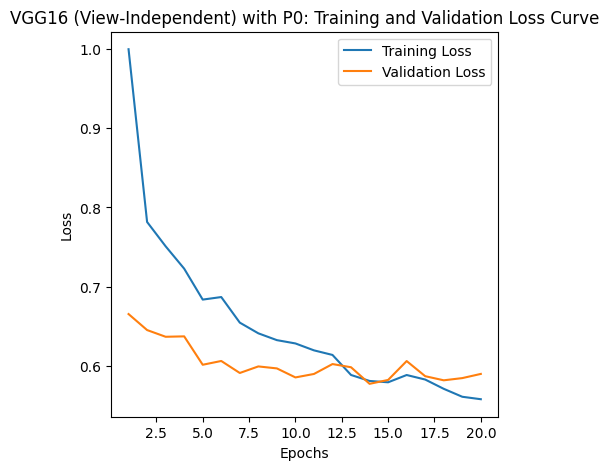

In [ ]:
# Training-Validation Loss curve for P0 pipeline
plot_training_validation_loss(vgg16_p0.history, 'VGG16 (View-Independent)', 'P0')

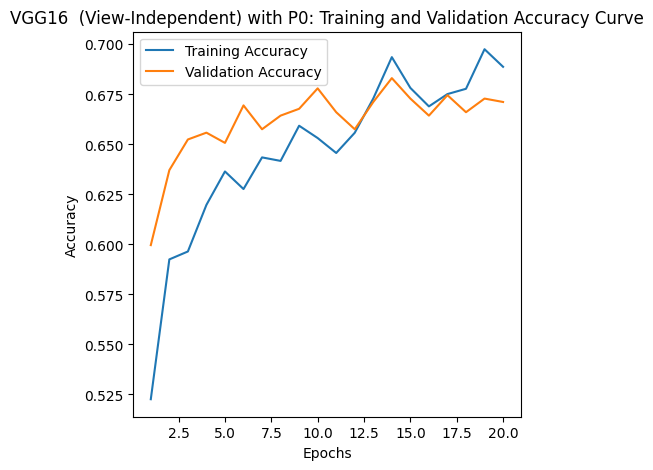

In [ ]:
# Training-Validation Accuracy curve for P0 pipeline
plot_training_validation_accuracy(vgg16_p0.history, 'VGG16  (View-Independent)', 'P0')

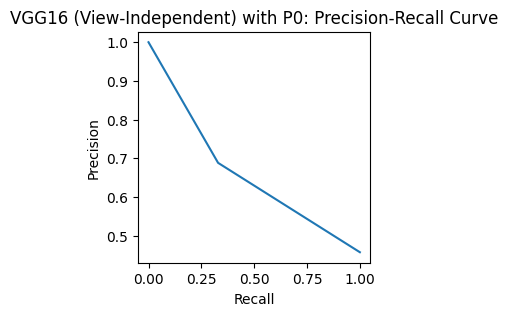

In [ ]:
# Precision-Recall curve for P0 Pipeline
plot_precision_recall_curve(true_pathology_np, predictions_p0, 'VGG16 (View-Independent)', 'P0')

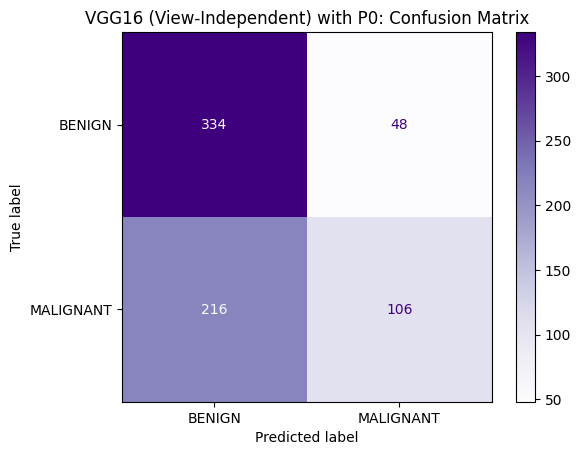

In [ ]:
# Confusion matrix for P0 pipeline
plot_confusion_matrix(true_pathology_np, predictions_p0, 'VGG16 (View-Independent)', 'P0')

## P1 Image Preprocessing Pipeline Experiment

* Resizing
* Grayscaling
* Normalization

In [ ]:
# Select the p1 image preprocessor function from the image preprocessor dictionary
p1 = IMAGE_PREPROCESSORS['P1']

In [ ]:
# Create a tf.data dataset with p1 image preprocessing
train_dataset_p1 = generate_dataset(train_df, 32, p1, 'vgg16', training=True)
val_dataset_p1 = generate_dataset(val_df, 32, p1, 'vgg16', training=False)
test_dataset_p1 = generate_dataset(test_df, 32, p1, 'vgg16', training=False)

In [ ]:
# Create a VGG16 model for p1 pipeline
vgg16_p1 = create_vgg16_model()
vgg16_p1 = compile_model(vgg16_p1)

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
# Train VGG16 with training dataset for p1 and compute its training time

# Reset memory for Peak GPU memory use computation
tf.config.experimental.reset_memory_stats('GPU:0')

# Training start time for p1
train_start_p1 = time.time()

# VGG16 with p1 training for 20 epochs
vgg16_p1.fit(train_dataset_p1, validation_data=val_dataset_p1, epochs=20)

# Memory used in p1
peak_memory_p1 = tf.config.experimental.get_memory_info('GPU:0')['peak']

# Training end time for p1
train_end_p1 = time.time()

# Total training time for p1 in minutes
training_time_p1 = (train_end_p1 - train_start_p1)

Epoch 1/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 57s 200ms/step - accuracy: 0.5226 - auc: 0.5200 - loss: 0.9992 - precision: 0.4042 - recall: 0.4248 - val_accuracy: 0.5997 - val_auc: 0.6315 - val_loss: 0.6658 - val_precision: 0.4857 - val_recall: 0.3696
Epoch 2/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 52s 200ms/step - accuracy: 0.5925 - auc: 0.6063 - loss: 0.7817 - precision: 0.4861 - recall: 0.4458 - val_accuracy: 0.6371 - val_auc: 0.6584 - val_loss: 0.6457 - val_precision: 0.5810 - val_recall: 0.2652
Epoch 3/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 50s 198ms/step - accuracy: 0.5965 - auc: 0.6269 - loss: 0.7511 - precision: 0.4914 - recall: 0.4436 - val_accuracy: 0.6525 - val_auc: 0.6759 - val_loss: 0.6372 - val_precision: 0.6667 - val_recall: 0.2261
Epoch 4/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 53s 211ms/step - accuracy: 0.6198 - auc: 0.6386 - loss: 0.7230 - precision: 0.5239 - recall: 0.4735 - val_accuracy: 0.6559 - val_auc: 0.6894 - val_loss: 0.6377 - val_precision: 0.7121 - val_recall: 0.2043
Epoch 5/20
72/72 ━━━━━━━━━━━

### P1 Image Preprocessing Predictions

In [ ]:
# Predict VGG16's prediction probabilities using test data for p1

# Prediction start time
predict_start_p1 = time.time()

# VGG16 with p1 predictions
prediction_probs_p1 = vgg16_p1.predict(test_dataset_p1)

# Prediction end time
predict_end_p1 = time.time()

# Total prediction time for p1 in seconds
prediction_time_p1 = predict_end_p1 - predict_start_p1

22/22 ━━━━━━━━━━━━━━━━━━━━ 6s 249ms/step


In [ ]:
# Evaluation metrics for VGG16 with p1
eval_metrics_p1 = vgg16_p1.evaluate(test_dataset_p1, return_dict=True)

22/22 ━━━━━━━━━━━━━━━━━━━━ 6s 260ms/step - accuracy: 0.6250 - auc: 0.6895 - loss: 0.6603 - precision: 0.6883 - recall: 0.3292


In [ ]:
# Compute predictions using model's prediction probabilities
predictions_p1 = np.where(prediction_probs_p1 > 0.5, 1.0, 0.0)

# Generate confusion matrix for p1 true and predicted values
tn_p1, fp_p1, fn_p1, tp_p1 = confusion_matrix(true_pathology, predictions_p1).ravel()

# Compute specificity using CM
specificity_p1 = tn_p1 / (tn_p1 + fp_p1)

# Compute F1 Score using recall and precision
f1_score_p1 = 0.0
if eval_metrics_p1['precision'] + eval_metrics_p1['recall'] != 0.0:
  f1_score_p1 = (2 * eval_metrics_p1['precision'] * eval_metrics_p1['recall']) / (eval_metrics_p1['precision'] + eval_metrics_p1['recall'])

# Parameters of VGG16 View-Independent model
vgg16_params_p1 = vgg16_p1.count_params()

In [ ]:
# Generate a results dataframe for results of p1 experiment
results_p1 = generate_results_df('VGG16', 'View_Independent', 'P1', eval_metrics_p1, specificity_p1, f1_score_p1, training_time_p1, prediction_time_p1, peak_memory_p1, vgg16_params_p1)

# Store p1 results into image preprocessing results csv
store_image_experiment_results(results_file_path, results_p1)

Stored results for 0    P1
Name: image_preprocessing_pipeline, dtype: object pipeline


### P1 Image Preprocessing Graphs

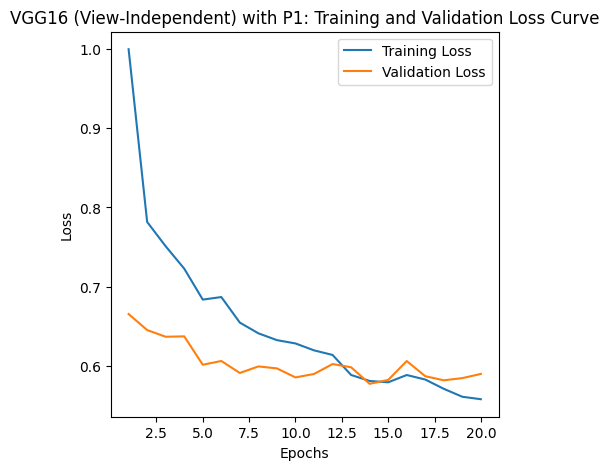

In [ ]:
# Training-Validation Loss curve for P1 pipeline
plot_training_validation_loss(vgg16_p1.history, 'VGG16 (View-Independent)', 'P1')

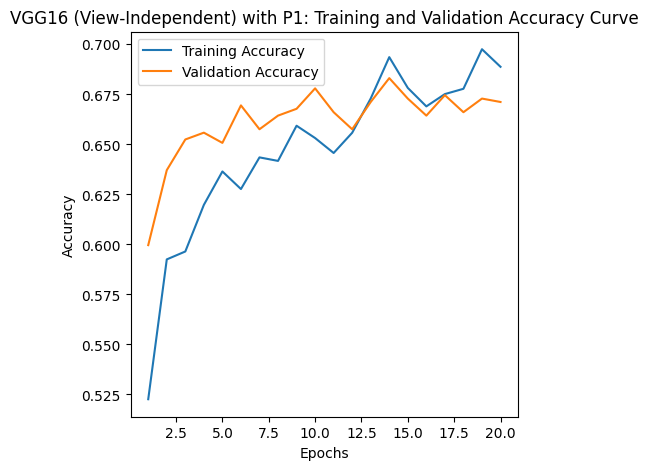

In [ ]:
# Training-Validation Accuracy curve for P1 pipeline
plot_training_validation_accuracy(vgg16_p1.history, 'VGG16 (View-Independent)', 'P1')

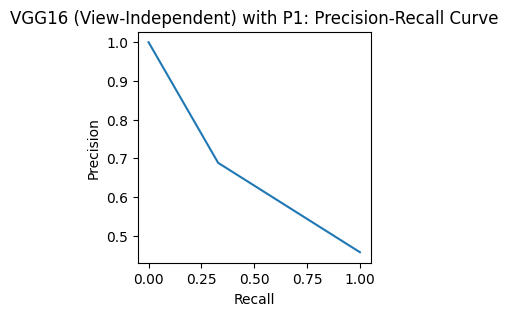

In [ ]:
# Precision-Recall curve for P1 Pipeline
plot_precision_recall_curve(true_pathology_np, predictions_p1, 'VGG16 (View-Independent)', 'P1')

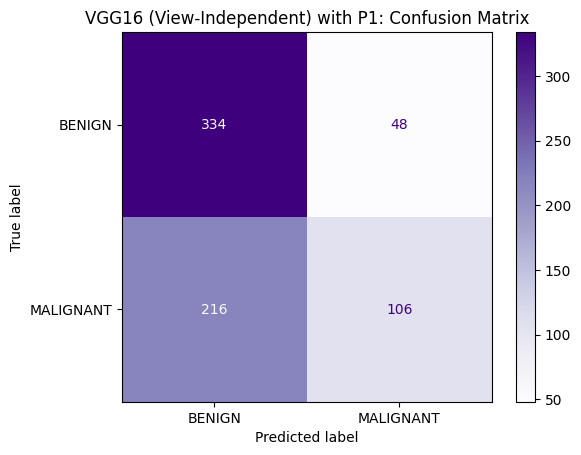

In [ ]:
# Confusion matrix for P1 pipeline
plot_confusion_matrix(true_pathology_np, predictions_p1, 'VGG16 (View-Independent)', 'P1')

## P2 Image Preprocessing Pipeline Experiment

* Resizing
* CLAHE
* Normalization

In [ ]:
# Select the p2 image preprocessor function from the image preprocessor dictionary
p2 = IMAGE_PREPROCESSORS['P2']

In [ ]:
# Create a tf.data dataset with p2 image preprocessing
train_dataset_p2 = generate_dataset(train_df, 32, p2, 'vgg16', training=True)
val_dataset_p2 = generate_dataset(val_df, 32, p2, 'vgg16', training=False)
test_dataset_p2 = generate_dataset(test_df, 32, p2, 'vgg16', training=False)

In [ ]:
# Create a VGG16 model for p2 pipeline
vgg16_p2 = create_vgg16_model()
vgg16_p2 = compile_model(vgg16_p2)

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
# Train VGG16 with training dataset for p2 and compute its training time

# Reset memory for Peak GPU memory use computation
tf.config.experimental.reset_memory_stats('GPU:0')

# Training start time for p2
train_start_p2 = time.time()

# VGG16 with p2 training for 20 epochs
vgg16_p2.fit(train_dataset_p2, validation_data=val_dataset_p2, epochs=20)

# Memory used in p2
peak_memory_p2 = tf.config.experimental.get_memory_info('GPU:0')['peak']

# Training end time for p2
train_end_p2 = time.time()

# Total training time for p2 in minutes
training_time_p2 = (train_end_p2 - train_start_p2)

Epoch 1/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 60s 193ms/step - accuracy: 0.5231 - auc: 0.5099 - loss: 1.0426 - precision: 0.4038 - recall: 0.4204 - val_accuracy: 0.5963 - val_auc: 0.6166 - val_loss: 0.6903 - val_precision: 0.4788 - val_recall: 0.3435
Epoch 2/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 53s 190ms/step - accuracy: 0.5855 - auc: 0.5988 - loss: 0.7991 - precision: 0.4768 - recall: 0.4425 - val_accuracy: 0.6269 - val_auc: 0.6460 - val_loss: 0.6808 - val_precision: 0.5567 - val_recall: 0.2348
Epoch 3/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 52s 188ms/step - accuracy: 0.5881 - auc: 0.6206 - loss: 0.7597 - precision: 0.4800 - recall: 0.4381 - val_accuracy: 0.6354 - val_auc: 0.6650 - val_loss: 0.6616 - val_precision: 0.5952 - val_recall: 0.2174
Epoch 4/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 53s 188ms/step - accuracy: 0.6145 - auc: 0.6319 - loss: 0.7413 - precision: 0.5160 - recall: 0.4812 - val_accuracy: 0.6252 - val_auc: 0.6730 - val_loss: 0.6751 - val_precision: 0.5862 - val_recall: 0.1478
Epoch 5/20
72/72 ━━━━━━━━━━━

### P2 Image Preprocessing Predictions

In [ ]:
# Predict VGG16's prediction probabilities using test data for p2

# Prediction start time
predict_start_p2 = time.time()

# VGG16 with p2 predictions
prediction_probs_p2 = vgg16_p2.predict(test_dataset_p2)

# Prediction end time
predict_end_p2 = time.time()

# Total prediction time for p2 in seconds
prediction_time_p2 = predict_end_p2 - predict_start_p2

22/22 ━━━━━━━━━━━━━━━━━━━━ 6s 272ms/step


In [ ]:
# Evaluation metrics for VGG16 with p2
eval_metrics_p2 = vgg16_p2.evaluate(test_dataset_p2, return_dict=True)

22/22 ━━━━━━━━━━━━━━━━━━━━ 5s 231ms/step - accuracy: 0.6122 - auc: 0.6987 - loss: 0.6541 - precision: 0.6581 - recall: 0.3168


In [ ]:
# Compute predictions using model's prediction probabilities
predictions_p2 = np.where(prediction_probs_p2 > 0.5, 1.0, 0.0)

# Generate confusion matrix for p2 true and predicted values
tn_p2, fp_p2, fn_p2, tp_p2 = confusion_matrix(true_pathology, predictions_p2).ravel()

# Compute specificity using CM
specificity_p2 = tn_p2 / (tn_p2 + fp_p2)

# Compute F1 Score using recall and precision
f1_score_p2 = 0.0
if eval_metrics_p2['precision'] + eval_metrics_p2['recall'] != 0.0:
  f1_score_p2 = (2 * eval_metrics_p2['precision'] * eval_metrics_p2['recall']) / (eval_metrics_p2['precision'] + eval_metrics_p2['recall'])

# Parameters of VGG16 View-Independent model
vgg16_params_p2 = vgg16_p2.count_params()

In [ ]:
# Generate a results dataframe for results of p2 experiment
results_p2 = generate_results_df('VGG16', 'View_Independent', 'P2', eval_metrics_p2, specificity_p2, f1_score_p2, training_time_p2, prediction_time_p2, peak_memory_p2, vgg16_params_p2)

# Store p2 results into image preprocessing results csv
store_image_experiment_results(results_file_path, results_p2)

Stored results for 0    P2
Name: image_preprocessing_pipeline, dtype: object pipeline


### P2 Image Preprocessing Graphs

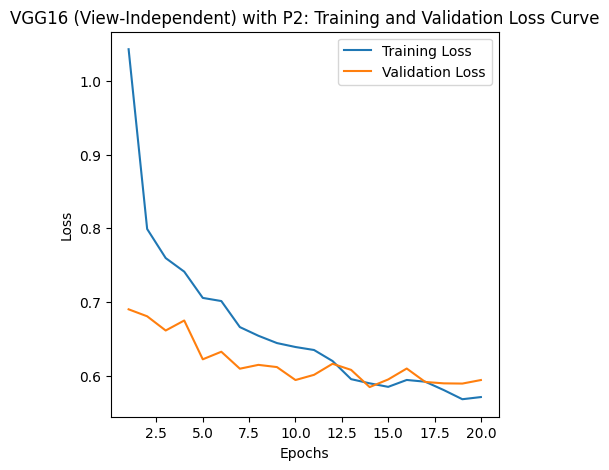

In [ ]:
# Training-Validation Loss curve for P2 pipeline
plot_training_validation_loss(vgg16_p2.history, 'VGG16 (View-Independent)', 'P2')

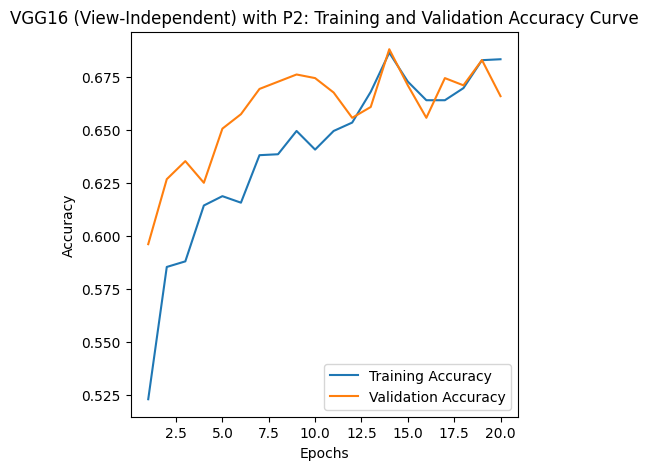

In [ ]:
# Training-Validation Accuracy curve for P2 pipeline
plot_training_validation_accuracy(vgg16_p2.history, 'VGG16 (View-Independent)', 'P2')

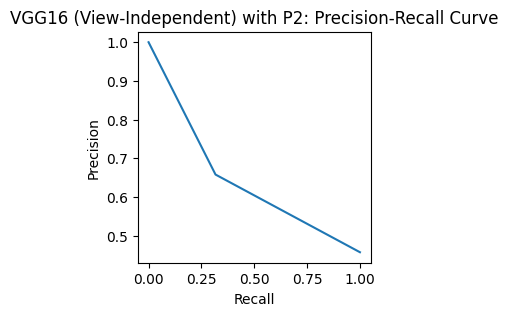

In [ ]:
# Precision-Recall curve for P2 Pipeline
plot_precision_recall_curve(true_pathology_np, predictions_p2, 'VGG16 (View-Independent)', 'P2')

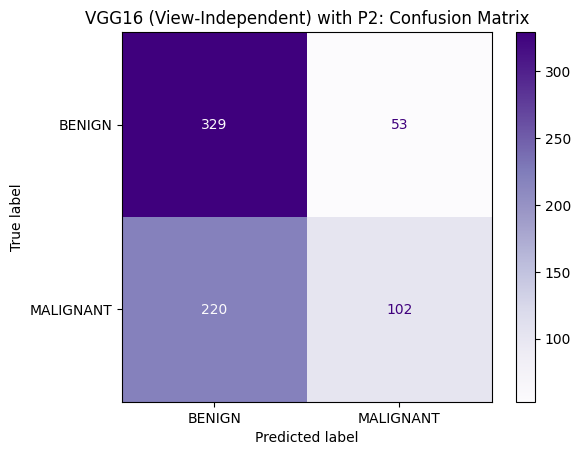

In [ ]:
# Confusion matrix for P2 pipeline
plot_confusion_matrix(true_pathology_np, predictions_p2, 'VGG16 (View-Independent)', 'P2')

## P3 Image Preprocessing Pipeline Experiment

* Resizing
* Gamma Correction
* Normalization

In [ ]:
# Select the p3 image preprocessor function from the image preprocessor dictionary
p3 = IMAGE_PREPROCESSORS['P3']

In [ ]:
# Create a tf.data dataset with p3 image preprocessing
train_dataset_p3 = generate_dataset(train_df, 32, p3, 'vgg16', training=True)
val_dataset_p3 = generate_dataset(val_df, 32, p3, 'vgg16', training=False)
test_dataset_p3 = generate_dataset(test_df, 32, p3, 'vgg16', training=False)

In [ ]:
# Create a VGG16 model for p3 pipeline
vgg16_p3 = create_vgg16_model()
vgg16_p3 = compile_model(vgg16_p3)

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step


In [ ]:
# Train VGG16 with training dataset for p3 and compute its training time

# Reset memory for Peak GPU memory use computation
tf.config.experimental.reset_memory_stats('GPU:0')

# Training start time for p3
train_start_p3 = time.time()

# VGG16 with p3 training for 20 epochs
vgg16_p3.fit(train_dataset_p3, validation_data=val_dataset_p3, epochs=20)

# Memory used in p3
peak_memory_p3 = tf.config.experimental.get_memory_info('GPU:0')['peak']

# Training end time for p3
train_end_p3 = time.time()

# Total training time for p3 in minutes
training_time_p3 = (train_end_p3 - train_start_p3)

Epoch 1/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 60s 201ms/step - accuracy: 0.5262 - auc: 0.5240 - loss: 1.0429 - precision: 0.4114 - recall: 0.4469 - val_accuracy: 0.5911 - val_auc: 0.6317 - val_loss: 0.6582 - val_precision: 0.4667 - val_recall: 0.3043
Epoch 2/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 50s 182ms/step - accuracy: 0.5969 - auc: 0.6050 - loss: 0.8041 - precision: 0.4923 - recall: 0.4569 - val_accuracy: 0.6440 - val_auc: 0.6576 - val_loss: 0.6430 - val_precision: 0.6129 - val_recall: 0.2478
Epoch 3/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 52s 186ms/step - accuracy: 0.5930 - auc: 0.6235 - loss: 0.7668 - precision: 0.4868 - recall: 0.4502 - val_accuracy: 0.6422 - val_auc: 0.6759 - val_loss: 0.6334 - val_precision: 0.6087 - val_recall: 0.2435
Epoch 4/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 53s 196ms/step - accuracy: 0.6088 - auc: 0.6365 - loss: 0.7341 - precision: 0.5084 - recall: 0.4679 - val_accuracy: 0.6559 - val_auc: 0.6855 - val_loss: 0.6319 - val_precision: 0.6628 - val_recall: 0.2478
Epoch 5/20
72/72 ━━━━━━━━━━━

### P3 Image Preprocessing Predictions

In [ ]:
# Predict VGG16's prediction probabilities using test data for p3

# Prediction start time
predict_start_p3 = time.time()

# VGG16 with p3 predictions
prediction_probs_p3 = vgg16_p3.predict(test_dataset_p3)

# Prediction end time
predict_end_p3 = time.time()

# Total prediction time for p3 in seconds
prediction_time_p3 = predict_end_p3 - predict_start_p3

22/22 ━━━━━━━━━━━━━━━━━━━━ 5s 234ms/step


In [ ]:
# Evaluation metrics for VGG16 with p3
eval_metrics_p3 = vgg16_p3.evaluate(test_dataset_p3, return_dict=True)

22/22 ━━━━━━━━━━━━━━━━━━━━ 6s 277ms/step - accuracy: 0.5923 - auc: 0.6722 - loss: 0.6651 - precision: 0.6296 - recall: 0.2640


In [ ]:
# Compute predictions using model's prediction probabilities
predictions_p3 = np.where(prediction_probs_p3 > 0.5, 1.0, 0.0)

# Generate confusion matrix for p3 true and predicted values
tn_p3, fp_p3, fn_p3, tp_p3 = confusion_matrix(true_pathology, predictions_p3).ravel()

# Compute specificity using CM
specificity_p3 = tn_p3 / (tn_p3 + fp_p3)

# Compute F1 Score using recall and precision
f1_score_p3 = 0.0
if eval_metrics_p3['precision'] + eval_metrics_p3['recall'] != 0.0:
  f1_score_p3 = (2 * eval_metrics_p3['precision'] * eval_metrics_p3['recall']) / (eval_metrics_p3['precision'] + eval_metrics_p3['recall'])

# Parameters of VGG16 View-Independent model
vgg16_params_p3 = vgg16_p3.count_params()

In [ ]:
# Generate a results dataframe for results of p3 experiment
results_p3 = generate_results_df('VGG16', 'View_Independent', 'P3', eval_metrics_p3, specificity_p3, f1_score_p3, training_time_p3, prediction_time_p3, peak_memory_p3, vgg16_params_p3)

# Store p3 results into image preprocessing results csv
store_image_experiment_results(results_file_path, results_p3)

Stored results for 0    P3
Name: image_preprocessing_pipeline, dtype: object pipeline


### P3 Image Preprocessing Graphs

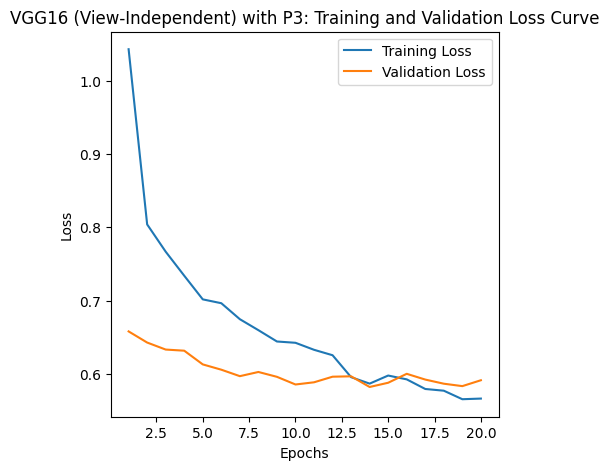

In [ ]:
# Training-Validation Loss curve for P3 pipeline
plot_training_validation_loss(vgg16_p3.history, 'VGG16 (View-Independent)', 'P3')

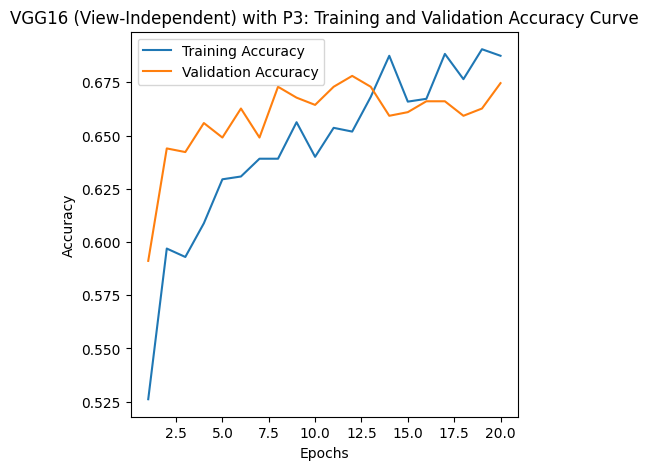

In [ ]:
# Training-Validation Accuracy curve for P3 pipeline
plot_training_validation_accuracy(vgg16_p3.history, 'VGG16 (View-Independent)', 'P3')

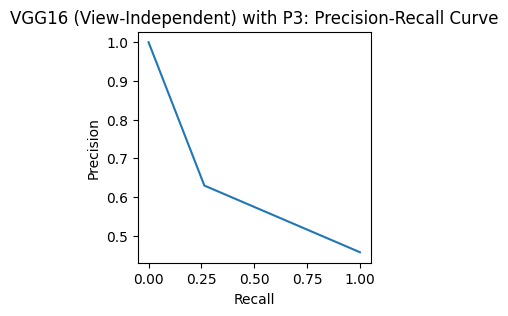

In [ ]:
# Precision-Recall curve for P3 Pipeline
plot_precision_recall_curve(true_pathology_np, predictions_p3, 'VGG16 (View-Independent)', 'P3')

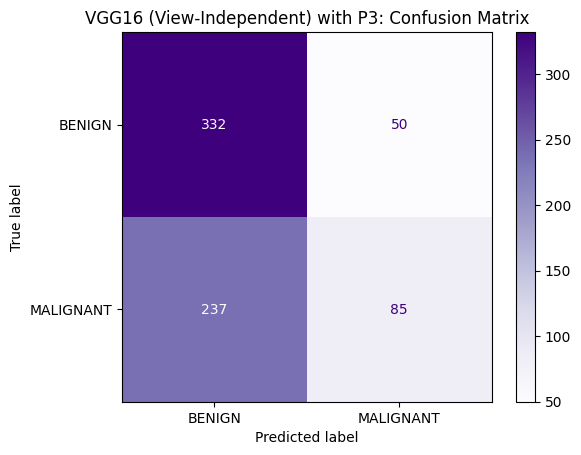

In [ ]:
# Confusion matrix for P3 pipeline
plot_confusion_matrix(true_pathology_np, predictions_p3, 'VGG16 (View-Independent)', 'P3')

## P4 Image Preprocessing Pipeline Experiment

* Resizing
* Median Blur
* Normalization

In [ ]:
# Select the p4 image preprocessor function from the image preprocessor dictionary
p4 = IMAGE_PREPROCESSORS['P4']

In [ ]:
# Create a tf.data dataset with p4 image preprocessing
train_dataset_p4 = generate_dataset(train_df, 32, p4, 'vgg16', training=True)
val_dataset_p4 = generate_dataset(val_df, 32, p4, 'vgg16', training=False)
test_dataset_p4 = generate_dataset(test_df, 32, p4, 'vgg16', training=False)

In [ ]:
# Create a VGG16 model for p4 pipeline
vgg16_p4 = create_vgg16_model()
vgg16_p4 = compile_model(vgg16_p4)

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step


In [ ]:
# Train VGG16 with training dataset for p4 and compute its training time

# Reset memory for Peak GPU memory use computation
tf.config.experimental.reset_memory_stats('GPU:0')

# Training start time for p4
train_start_p4 = time.time()

# VGG16 with p4 training for 20 epochs
vgg16_p4.fit(train_dataset_p4, validation_data=val_dataset_p4, epochs=20)

# Memory used in p4
peak_memory_p4 = tf.config.experimental.get_memory_info('GPU:0')['peak']

# Training end time for p4
train_end_p4 = time.time()

# Total training time for p4 in minutes
training_time_p4 = (train_end_p4 - train_start_p4)

Epoch 1/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 58s 191ms/step - accuracy: 0.5262 - auc: 0.5218 - loss: 1.0102 - precision: 0.4096 - recall: 0.4358 - val_accuracy: 0.5945 - val_auc: 0.6141 - val_loss: 0.6734 - val_precision: 0.4806 - val_recall: 0.4304
Epoch 2/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 53s 191ms/step - accuracy: 0.5925 - auc: 0.6051 - loss: 0.7820 - precision: 0.4861 - recall: 0.4458 - val_accuracy: 0.6269 - val_auc: 0.6433 - val_loss: 0.6435 - val_precision: 0.5364 - val_recall: 0.3522
Epoch 3/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 51s 188ms/step - accuracy: 0.5934 - auc: 0.6229 - loss: 0.7545 - precision: 0.4870 - recall: 0.4347 - val_accuracy: 0.6542 - val_auc: 0.6606 - val_loss: 0.6299 - val_precision: 0.6116 - val_recall: 0.3217
Epoch 4/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 53s 195ms/step - accuracy: 0.6189 - auc: 0.6407 - loss: 0.7170 - precision: 0.5230 - recall: 0.4657 - val_accuracy: 0.6610 - val_auc: 0.6698 - val_loss: 0.6257 - val_precision: 0.6505 - val_recall: 0.2913
Epoch 5/20
72/72 ━━━━━━━━━━━

### P4 Image Preprocessing Predictions

In [ ]:
# Predict VGG16's prediction probabilities using test data for p4

# Prediction start time
predict_start_p4 = time.time()

# VGG16 with p4 predictions
prediction_probs_p4 = vgg16_p4.predict(test_dataset_p4)

# Prediction end time
predict_end_p4 = time.time()

# Total prediction time for p4 in seconds
prediction_time_p4 = predict_end_p4 - predict_start_p4

22/22 ━━━━━━━━━━━━━━━━━━━━ 5s 228ms/step


In [ ]:
# Evaluation metrics for VGG16 with p4
eval_metrics_p4 = vgg16_p4.evaluate(test_dataset_p4, return_dict=True)

22/22 ━━━━━━━━━━━━━━━━━━━━ 5s 227ms/step - accuracy: 0.6122 - auc: 0.6749 - loss: 0.6556 - precision: 0.6433 - recall: 0.3416


In [ ]:
# Compute predictions using model's prediction probabilities
predictions_p4 = np.where(prediction_probs_p4 > 0.5, 1.0, 0.0)

# Generate confusion matrix for p4 true and predicted values
tn_p4, fp_p4, fn_p4, tp_p4 = confusion_matrix(true_pathology, predictions_p4).ravel()

# Compute specificity using CM
specificity_p4 = tn_p4 / (tn_p4 + fp_p4)

# Compute F1 Score using recall and precision
f1_score_p4 = 0.0
if eval_metrics_p4['precision'] + eval_metrics_p4['recall'] != 0.0:
  f1_score_p4 = (2 * eval_metrics_p4['precision'] * eval_metrics_p4['recall']) / (eval_metrics_p4['precision'] + eval_metrics_p4['recall'])

# Parameters of VGG16 View-Independent model
vgg16_params_p4 = vgg16_p4.count_params()

In [ ]:
# Generate a results dataframe for results of p4 experiment
results_p4 = generate_results_df('VGG16', 'View_Independent', 'P4', eval_metrics_p4, specificity_p4, f1_score_p4, training_time_p4, prediction_time_p4, peak_memory_p4, vgg16_params_p4)

# Store p4 results into image preprocessing results csv
store_image_experiment_results(results_file_path, results_p4)

Stored results for 0    P4
Name: image_preprocessing_pipeline, dtype: object pipeline


### P4 Image Preprocessing Graphs

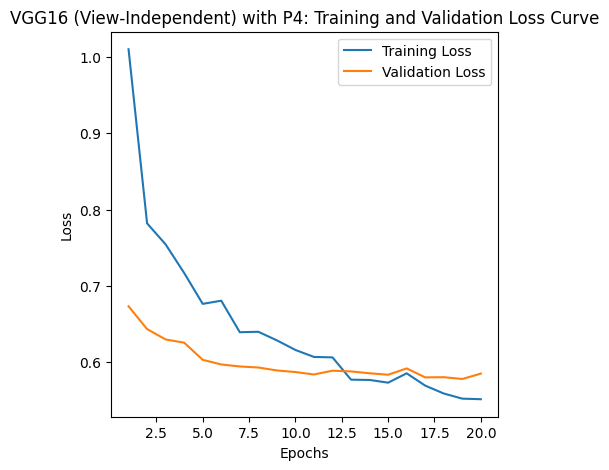

In [ ]:
# Training-Validation Loss curve for P4 pipeline
plot_training_validation_loss(vgg16_p4.history, 'VGG16 (View-Independent)', 'P4')

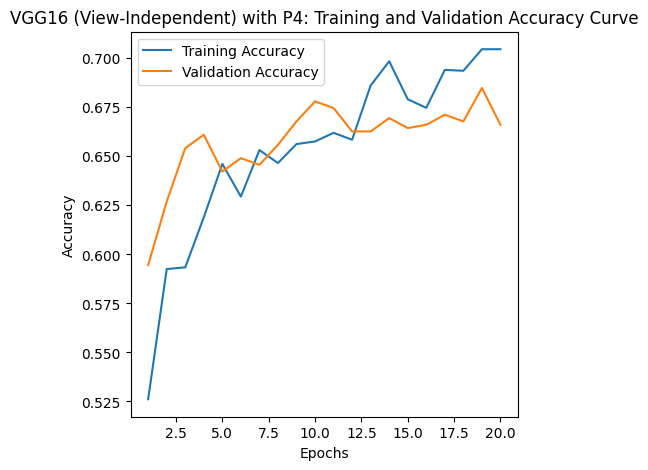

In [ ]:
# Training-Validation Accuracy curve for P4 pipeline
plot_training_validation_accuracy(vgg16_p4.history, 'VGG16 (View-Independent)', 'P4')

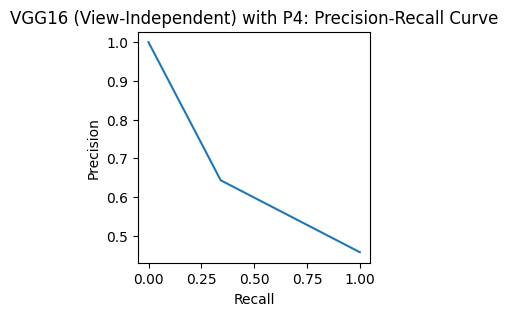

In [ ]:
# Precision-Recall curve for P4 Pipeline
plot_precision_recall_curve(true_pathology_np, predictions_p4, 'VGG16 (View-Independent)', 'P4')

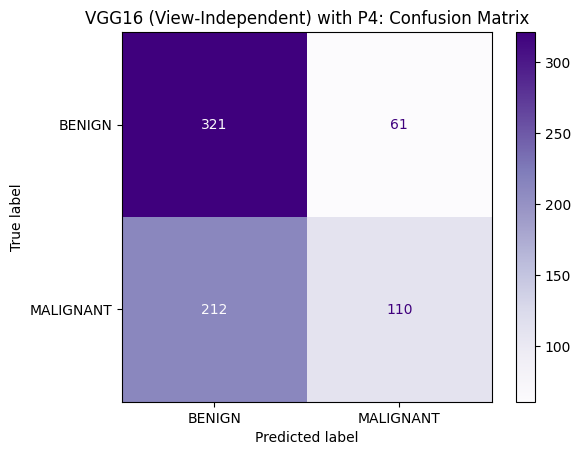

In [ ]:
# Confusion matrix for P4 pipeline
plot_confusion_matrix(true_pathology_np, predictions_p4, 'VGG16 (View-Independent)', 'P4')

## P5 Image Preprocessing Pipeline Experiment

* Resizing
* Grayscaling
* Gamma Correction
* Normalization

In [ ]:
# Select the p5 image preprocessor function from the image preprocessor dictionary
p5 = IMAGE_PREPROCESSORS['P5']

In [ ]:
# Create a tf.data dataset with p5 image preprocessing
train_dataset_p5 = generate_dataset(train_df, 32, p5, 'vgg16', training=True)
val_dataset_p5 = generate_dataset(val_df, 32, p5, 'vgg16', training=False)
test_dataset_p5 = generate_dataset(test_df, 32, p5, 'vgg16', training=False)

In [ ]:
# Create a VGG16 model for p5 pipeline
vgg16_p5 = create_vgg16_model()
vgg16_p5 = compile_model(vgg16_p5)

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
# Train VGG16 with training dataset for p5 and compute its training time

# Reset memory for Peak GPU memory use computation
tf.config.experimental.reset_memory_stats('GPU:0')

# Training start time for p5
train_start_p5 = time.time()

# VGG16 with p5 training for 20 epochs
vgg16_p5.fit(train_dataset_p5, validation_data=val_dataset_p5, epochs=20)

# Memory used in p5
peak_memory_p5 = tf.config.experimental.get_memory_info('GPU:0')['peak']

# Training end time for p5
train_end_p5 = time.time()

# Total training time for p5 in minutes
training_time_p5 = (train_end_p5 - train_start_p5)

Epoch 1/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 60s 203ms/step - accuracy: 0.5262 - auc: 0.5240 - loss: 1.0429 - precision: 0.4114 - recall: 0.4469 - val_accuracy: 0.5911 - val_auc: 0.6317 - val_loss: 0.6582 - val_precision: 0.4667 - val_recall: 0.3043
Epoch 2/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 51s 190ms/step - accuracy: 0.5969 - auc: 0.6050 - loss: 0.8041 - precision: 0.4923 - recall: 0.4569 - val_accuracy: 0.6440 - val_auc: 0.6576 - val_loss: 0.6430 - val_precision: 0.6129 - val_recall: 0.2478
Epoch 3/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 52s 194ms/step - accuracy: 0.5930 - auc: 0.6235 - loss: 0.7668 - precision: 0.4868 - recall: 0.4502 - val_accuracy: 0.6422 - val_auc: 0.6759 - val_loss: 0.6334 - val_precision: 0.6087 - val_recall: 0.2435
Epoch 4/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 52s 201ms/step - accuracy: 0.6088 - auc: 0.6365 - loss: 0.7341 - precision: 0.5084 - recall: 0.4679 - val_accuracy: 0.6559 - val_auc: 0.6855 - val_loss: 0.6319 - val_precision: 0.6628 - val_recall: 0.2478
Epoch 5/20
72/72 ━━━━━━━━━━━

### P5 Image Preprocessing Predictions

In [ ]:
# Predict VGG16's prediction probabilities using test data for p5

# Prediction start time
predict_start_p5 = time.time()

# VGG16 with p5 predictions
prediction_probs_p5 = vgg16_p5.predict(test_dataset_p5)

# Prediction end time
predict_end_p5 = time.time()

# Total prediction time for p5 in seconds
prediction_time_p5 = predict_end_p5 - predict_start_p5

22/22 ━━━━━━━━━━━━━━━━━━━━ 6s 243ms/step


In [ ]:
# Evaluation metrics for VGG16 with p5
eval_metrics_p5 = vgg16_p5.evaluate(test_dataset_p5, return_dict=True)

22/22 ━━━━━━━━━━━━━━━━━━━━ 6s 277ms/step - accuracy: 0.5923 - auc: 0.6722 - loss: 0.6651 - precision: 0.6296 - recall: 0.2640


In [ ]:
# Compute predictions using model's prediction probabilities
predictions_p5 = np.where(prediction_probs_p5 > 0.5, 1.0, 0.0)

# Generate confusion matrix for p5 true and predicted values
tn_p5, fp_p5, fn_p5, tp_p5 = confusion_matrix(true_pathology, predictions_p5).ravel()

# Compute specificity using CM
specificity_p5 = tn_p5 / (tn_p5 + fp_p5)

# Compute F1 Score using recall and precision
f1_score_p5 = 0.0
if eval_metrics_p5['precision'] + eval_metrics_p5['recall'] != 0.0:
  f1_score_p5 = (2 * eval_metrics_p5['precision'] * eval_metrics_p5['recall']) / (eval_metrics_p5['precision'] + eval_metrics_p5['recall'])

# Parameters of VGG16 View-Independent model
vgg16_params_p5 = vgg16_p5.count_params()

In [ ]:
# Generate a results dataframe for results of p5 experiment
results_p5 = generate_results_df('VGG16', 'View_Independent', 'P5', eval_metrics_p5, specificity_p5, f1_score_p5, training_time_p5, prediction_time_p5, peak_memory_p5, vgg16_params_p5)

# Store p5 results into image preprocessing results csv
store_image_experiment_results(results_file_path, results_p5)

Stored results for 0    P5
Name: image_preprocessing_pipeline, dtype: object pipeline


### P5 Image Preprocessing Graphs

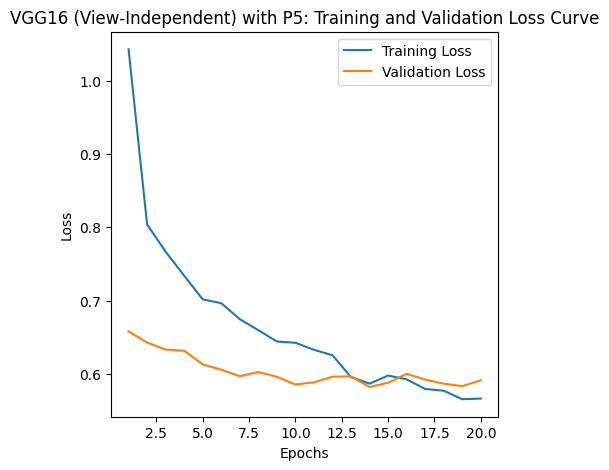

In [ ]:
# Training-Validation Loss curve for P5 pipeline
plot_training_validation_loss(vgg16_p5.history, 'VGG16 (View-Independent)', 'P5')

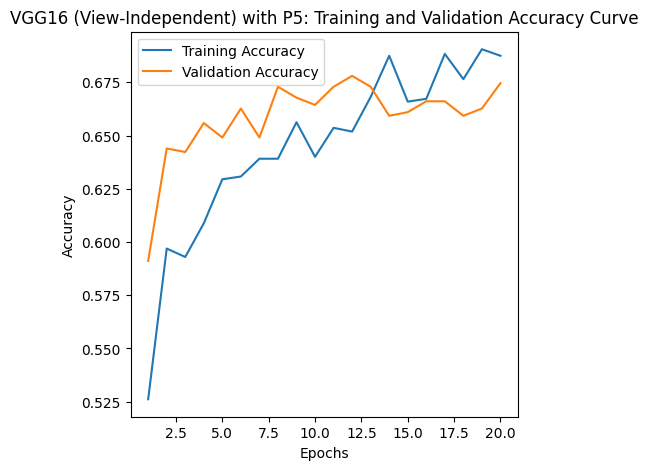

In [ ]:
# Training-Validation Accuracy curve for P5 pipeline
plot_training_validation_accuracy(vgg16_p5.history, 'VGG16 (View-Independent)', 'P5')

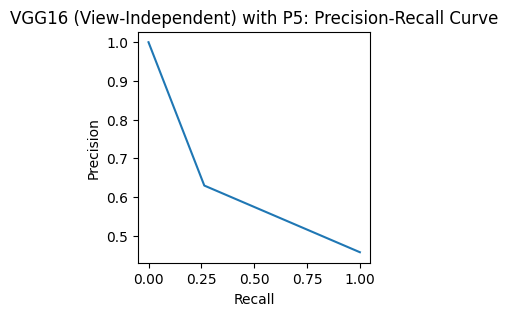

In [ ]:
# Precision-Recall curve for P5 Pipeline
plot_precision_recall_curve(true_pathology_np, predictions_p5, 'VGG16 (View-Independent)', 'P5')

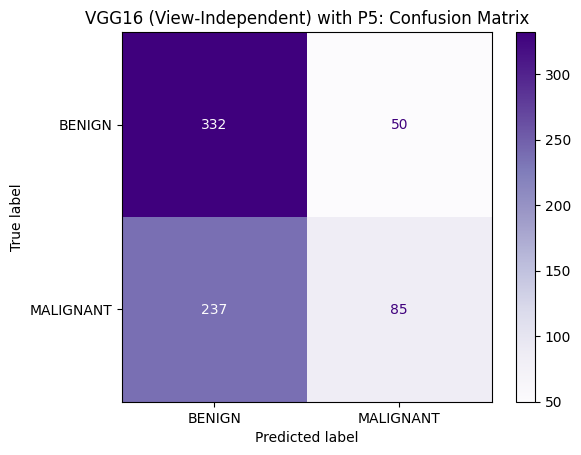

In [ ]:
# Confusion matrix for P5 pipeline
plot_confusion_matrix(true_pathology_np, predictions_p5, 'VGG16 (View-Independent)', 'P5')

## P6 Image Preprocessing Pipeline Experiment

* Resizing
* Grayscaling
* Median Blur
* Normalization

In [ ]:
# Select the p6 image preprocessor function from the image preprocessor dictionary
p6 = IMAGE_PREPROCESSORS['P6']

In [ ]:
# Create a tf.data dataset with p6 image preprocessing
train_dataset_p6 = generate_dataset(train_df, 32, p6, 'vgg16', training=True)
val_dataset_p6 = generate_dataset(val_df, 32, p6, 'vgg16', training=False)
test_dataset_p6 = generate_dataset(test_df, 32, p6, 'vgg16', training=False)

In [ ]:
# Create a VGG16 model for p6 pipeline
vgg16_p6 = create_vgg16_model()
vgg16_p6 = compile_model(vgg16_p6)

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step


In [ ]:
# Train VGG16 with training dataset for p6 and compute its training time

# Reset memory for Peak GPU memory use computation
tf.config.experimental.reset_memory_stats('GPU:0')

# Training start time for p6
train_start_p6 = time.time()

# VGG16 with p6 training for 20 epochs
vgg16_p6.fit(train_dataset_p6, validation_data=val_dataset_p6, epochs=20)

# Memory used in p6
peak_memory_p6 = tf.config.experimental.get_memory_info('GPU:0')['peak']

# Training end time for p6
train_end_p6 = time.time()

# Total training time for p6 in minutes
training_time_p6 = (train_end_p6 - train_start_p6)

Epoch 1/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 62s 223ms/step - accuracy: 0.5262 - auc: 0.5218 - loss: 1.0102 - precision: 0.4096 - recall: 0.4358 - val_accuracy: 0.5945 - val_auc: 0.6141 - val_loss: 0.6734 - val_precision: 0.4806 - val_recall: 0.4304
Epoch 2/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 60s 218ms/step - accuracy: 0.5925 - auc: 0.6051 - loss: 0.7820 - precision: 0.4861 - recall: 0.4458 - val_accuracy: 0.6269 - val_auc: 0.6433 - val_loss: 0.6435 - val_precision: 0.5364 - val_recall: 0.3522
Epoch 3/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 57s 226ms/step - accuracy: 0.5934 - auc: 0.6229 - loss: 0.7545 - precision: 0.4870 - recall: 0.4347 - val_accuracy: 0.6542 - val_auc: 0.6606 - val_loss: 0.6299 - val_precision: 0.6116 - val_recall: 0.3217
Epoch 4/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 60s 224ms/step - accuracy: 0.6189 - auc: 0.6407 - loss: 0.7170 - precision: 0.5230 - recall: 0.4657 - val_accuracy: 0.6610 - val_auc: 0.6698 - val_loss: 0.6257 - val_precision: 0.6505 - val_recall: 0.2913
Epoch 5/20
72/72 ━━━━━━━━━━━

### P6 Image Preprocessing Predictions

In [ ]:
# Predict VGG16's prediction probabilities using test data for p6

# Prediction start time
predict_start_p6 = time.time()

# VGG16 with p6 predictions
prediction_probs_p6 = vgg16_p6.predict(test_dataset_p6)

# Prediction end time
predict_end_p6 = time.time()

# Total prediction time for p6 in seconds
prediction_time_p6 = predict_end_p6 - predict_start_p6

22/22 ━━━━━━━━━━━━━━━━━━━━ 6s 260ms/step


In [ ]:
# Evaluation metrics for VGG16 with p6
eval_metrics_p6 = vgg16_p6.evaluate(test_dataset_p6, return_dict=True)

22/22 ━━━━━━━━━━━━━━━━━━━━ 6s 250ms/step - accuracy: 0.6122 - auc: 0.6749 - loss: 0.6556 - precision: 0.6433 - recall: 0.3416


In [ ]:
# Compute predictions using model's prediction probabilities
predictions_p6 = np.where(prediction_probs_p6 > 0.5, 1.0, 0.0)

# Generate confusion matrix for p6 true and predicted values
tn_p6, fp_p6, fn_p6, tp_p6 = confusion_matrix(true_pathology, predictions_p6).ravel()

# Compute specificity using CM
specificity_p6 = tn_p6 / (tn_p6 + fp_p6)

# Compute F1 Score using recall and precision
f1_score_p6 = 0.0
if eval_metrics_p6['precision'] + eval_metrics_p6['recall'] != 0.0:
  f1_score_p6 = (2 * eval_metrics_p6['precision'] * eval_metrics_p6['recall']) / (eval_metrics_p6['precision'] + eval_metrics_p6['recall'])

# Parameters of VGG16 View-Independent model
vgg16_params_p6 = vgg16_p6.count_params()

In [ ]:
# Generate a results dataframe for results of p6 experiment
results_p6 = generate_results_df('VGG16', 'View_Independent', 'P6', eval_metrics_p6, specificity_p6, f1_score_p6, training_time_p6, prediction_time_p6, peak_memory_p6, vgg16_params_p6)

# Store p6 results into image preprocessing results csv
store_image_experiment_results(results_file_path, results_p6)

Stored results for 0    P6
Name: image_preprocessing_pipeline, dtype: object pipeline


### P6 Image Preprocessing Graphs

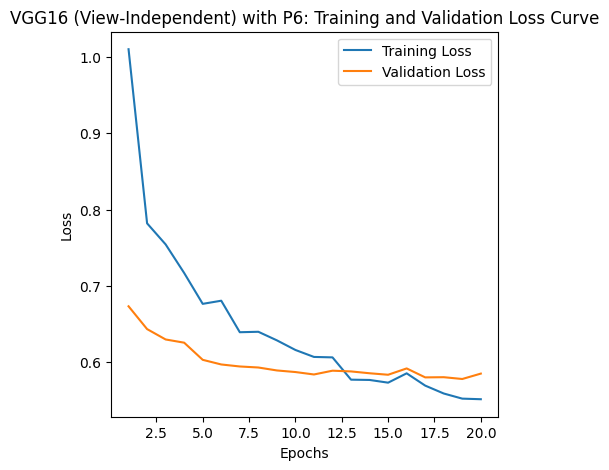

In [ ]:
# Training-Validation Loss curve for P6 pipeline
plot_training_validation_loss(vgg16_p6.history, 'VGG16 (View-Independent)', 'P6')

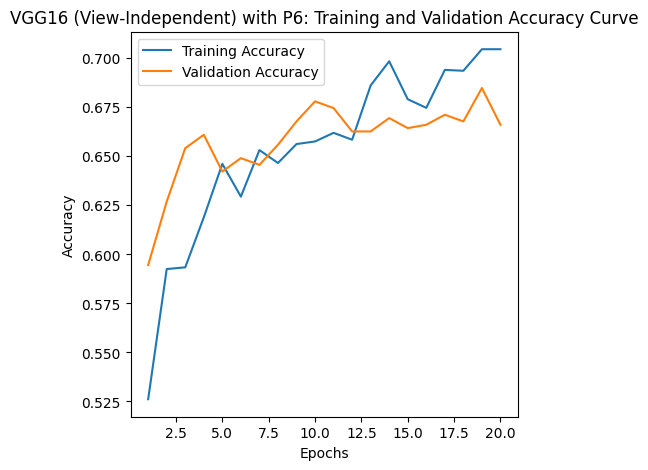

In [ ]:
# Training-Validation Accuracy curve for P6 pipeline
plot_training_validation_accuracy(vgg16_p6.history, 'VGG16 (View-Independent)', 'P6')

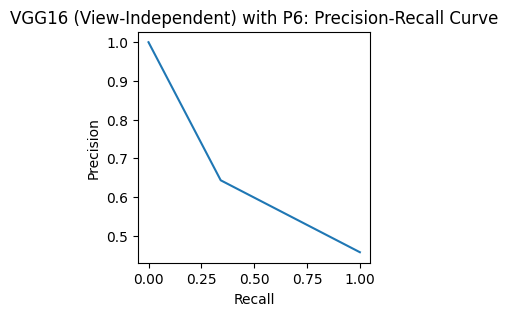

In [ ]:
# Precision-Recall curve for P6 Pipeline
plot_precision_recall_curve(true_pathology_np, predictions_p6, 'VGG16 (View-Independent)', 'P6')

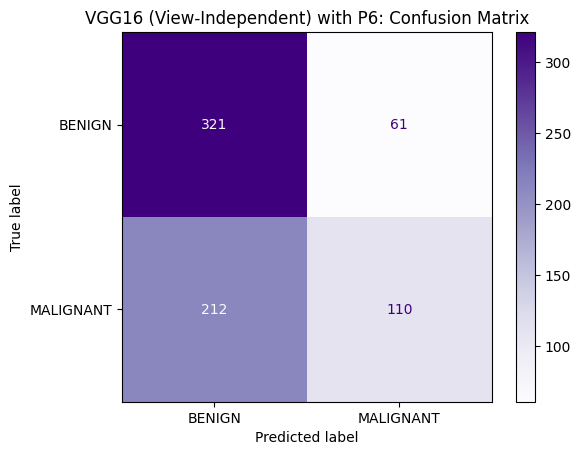

In [ ]:
# Confusion matrix for P6 pipeline
plot_confusion_matrix(true_pathology_np, predictions_p6, 'VGG16 (View-Independent)', 'P6')

## P7 Image Preprocessing Pipeline Experiment

* Resizing
* CLAHE
* Gamma Correction
* Normalization

In [ ]:
# Select the p7 image preprocessor function from the image preprocessor dictionary
p7 = IMAGE_PREPROCESSORS['P7']

In [ ]:
# Create a tf.data dataset with p7 image preprocessing
train_dataset_p7 = generate_dataset(train_df, 32, p7, 'vgg16', training=True)
val_dataset_p7 = generate_dataset(val_df, 32, p7, 'vgg16', training=False)
test_dataset_p7 = generate_dataset(test_df, 32, p7, 'vgg16', training=False)

In [ ]:
# Create a VGG16 model for p7 pipeline
vgg16_p7 = create_vgg16_model()
vgg16_p7 = compile_model(vgg16_p7)

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step


In [ ]:
# Train VGG16 with training dataset for p7 and compute its training time

# Reset memory for Peak GPU memory use computation
tf.config.experimental.reset_memory_stats('GPU:0')

# Training start time for p7
train_start_p7 = time.time()

# VGG16 with p7 training for 20 epochs
vgg16_p7.fit(train_dataset_p7, validation_data=val_dataset_p7, epochs=20)

# Memory used in p7
peak_memory_p7 = tf.config.experimental.get_memory_info('GPU:0')['peak']

# Training end time for p7
train_end_p7 = time.time()

# Total training time for p7 in minutes
training_time_p7 = (train_end_p7 - train_start_p7)

Epoch 1/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 63s 204ms/step - accuracy: 0.5099 - auc: 0.5124 - loss: 1.1085 - precision: 0.3938 - recall: 0.4325 - val_accuracy: 0.6014 - val_auc: 0.6286 - val_loss: 0.6692 - val_precision: 0.4877 - val_recall: 0.3435
Epoch 2/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 77s 200ms/step - accuracy: 0.5877 - auc: 0.5974 - loss: 0.8208 - precision: 0.4794 - recall: 0.4369 - val_accuracy: 0.6388 - val_auc: 0.6531 - val_loss: 0.6638 - val_precision: 0.5978 - val_recall: 0.2391
Epoch 3/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 56s 202ms/step - accuracy: 0.5903 - auc: 0.6162 - loss: 0.7778 - precision: 0.4833 - recall: 0.4480 - val_accuracy: 0.6525 - val_auc: 0.6717 - val_loss: 0.6502 - val_precision: 0.6477 - val_recall: 0.2478
Epoch 4/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 56s 208ms/step - accuracy: 0.6202 - auc: 0.6344 - loss: 0.7479 - precision: 0.5238 - recall: 0.4878 - val_accuracy: 0.6457 - val_auc: 0.6807 - val_loss: 0.6546 - val_precision: 0.6447 - val_recall: 0.2130
Epoch 5/20
72/72 ━━━━━━━━━━━

### P7 Image Preprocessing Predictions

In [ ]:
# Predict VGG16's prediction probabilities using test data for p7

# Prediction start time
predict_start_p7 = time.time()

# VGG16 with p7 predictions
prediction_probs_p7 = vgg16_p7.predict(test_dataset_p7)

# Prediction end time
predict_end_p7 = time.time()

# Total prediction time for p7 in seconds
prediction_time_p7 = predict_end_p7 - predict_start_p7

22/22 ━━━━━━━━━━━━━━━━━━━━ 7s 303ms/step


In [ ]:
# Evaluation metrics for VGG16 with p7
eval_metrics_p7 = vgg16_p7.evaluate(test_dataset_p7, return_dict=True)

22/22 ━━━━━━━━━━━━━━━━━━━━ 6s 263ms/step - accuracy: 0.6065 - auc: 0.6737 - loss: 0.6744 - precision: 0.6667 - recall: 0.2795


In [ ]:
# Compute predictions using model's prediction probabilities
predictions_p7 = np.where(prediction_probs_p7 > 0.5, 1.0, 0.0)

# Generate confusion matrix for p7 true and predicted values
tn_p7, fp_p7, fn_p7, tp_p7 = confusion_matrix(true_pathology, predictions_p7).ravel()

# Compute specificity using CM
specificity_p7 = tn_p7 / (tn_p7 + fp_p7)

# Compute F1 Score using recall and precision
f1_score_p7 = 0.0
if eval_metrics_p7['precision'] + eval_metrics_p7['recall'] != 0.0:
  f1_score_p7 = (2 * eval_metrics_p7['precision'] * eval_metrics_p7['recall']) / (eval_metrics_p7['precision'] + eval_metrics_p7['recall'])

# Parameters of VGG16 View-Independent model
vgg16_params_p7 = vgg16_p7.count_params()

In [ ]:
# Generate a results dataframe for results of p7 experiment
results_p7 = generate_results_df('VGG16', 'View_Independent', 'P7', eval_metrics_p7, specificity_p7, f1_score_p7, training_time_p7, prediction_time_p7, peak_memory_p7, vgg16_params_p7)

# Store p7 results into image preprocessing results csv
store_image_experiment_results(results_file_path, results_p7)

Stored results for 0    P7
Name: image_preprocessing_pipeline, dtype: object pipeline


### P7 Image Preprocessing Graphs

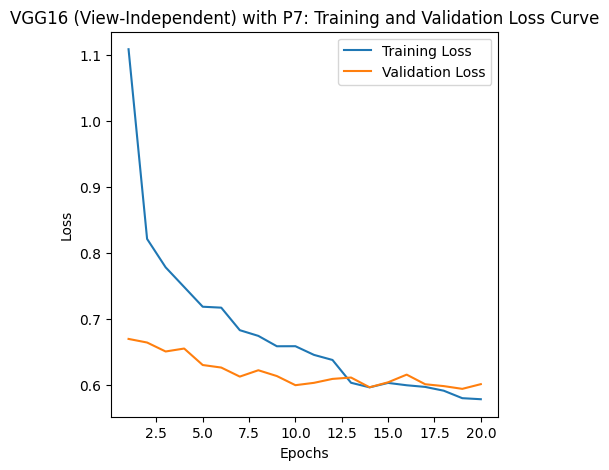

In [ ]:
# Training-Validation Loss curve for P7 pipeline
plot_training_validation_loss(vgg16_p7.history, 'VGG16 (View-Independent)', 'P7')

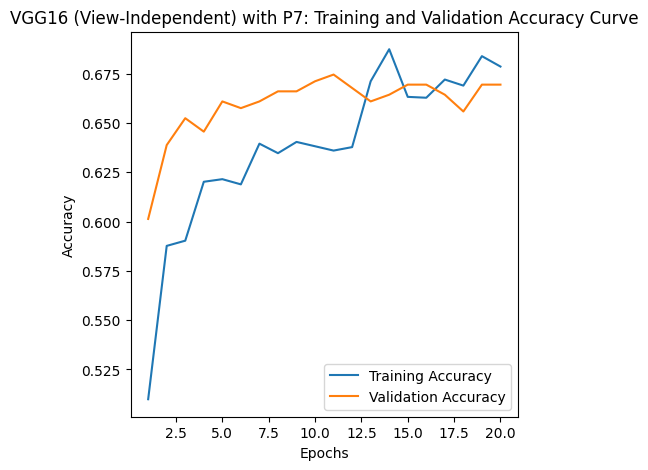

In [ ]:
# Training-Validation Accuracy curve for P7 pipeline
plot_training_validation_accuracy(vgg16_p7.history, 'VGG16 (View-Independent)', 'P7')

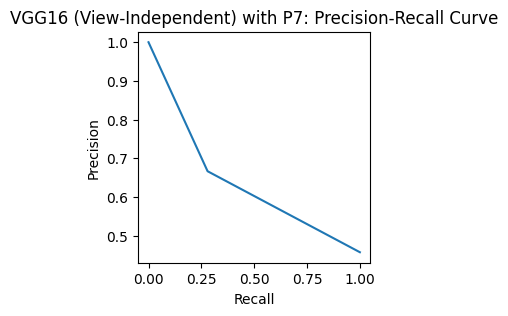

In [ ]:
# Precision-Recall curve for P7 Pipeline
plot_precision_recall_curve(true_pathology_np, predictions_p7, 'VGG16 (View-Independent)', 'P7')

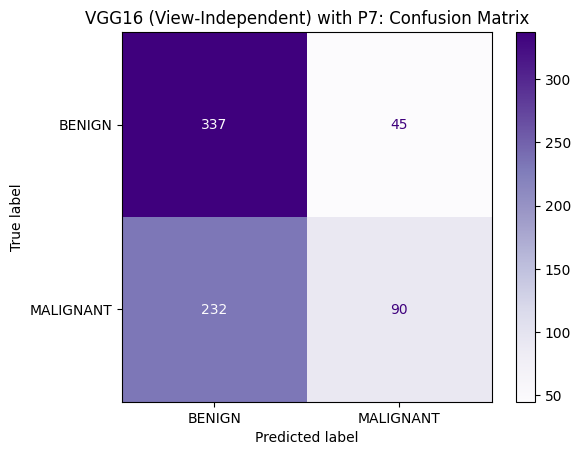

In [ ]:
# Confusion matrix for P7 pipeline
plot_confusion_matrix(true_pathology_np, predictions_p7, 'VGG16 (View-Independent)', 'P7')

## P8 Image Preprocessing Pipeline Experiment

* Resizing
* CLAHE
* Median Blur
* Normalization

In [ ]:
# Select the p8 image preprocessor function from the image preprocessor dictionary
p8 = IMAGE_PREPROCESSORS['P8']

In [ ]:
# Create a tf.data dataset with p8 image preprocessing
train_dataset_p8 = generate_dataset(train_df, 32, p8, 'vgg16', training=True)
val_dataset_p8 = generate_dataset(val_df, 32, p8, 'vgg16', training=False)
test_dataset_p8 = generate_dataset(test_df, 32, p8, 'vgg16', training=False)

In [ ]:
# Create a VGG16 model for p8 pipeline
vgg16_p8 = create_vgg16_model()
vgg16_p8 = compile_model(vgg16_p8)

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step


In [ ]:
# Train VGG16 with training dataset for p8 and compute its training time

# Reset memory for Peak GPU memory use computation
tf.config.experimental.reset_memory_stats('GPU:0')

# Training start time for p8
train_start_p8 = time.time()

# VGG16 with p8 training for 20 epochs
vgg16_p8.fit(train_dataset_p8, validation_data=val_dataset_p8, epochs=20)

# Memory used in p8
peak_memory_p8 = tf.config.experimental.get_memory_info('GPU:0')['peak']

# Training end time for p8
train_end_p8 = time.time()

# Total training time for p8 in minutes
training_time_p8 = (train_end_p8 - train_start_p8)

Epoch 1/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 62s 201ms/step - accuracy: 0.5099 - auc: 0.5096 - loss: 1.0571 - precision: 0.3916 - recall: 0.4215 - val_accuracy: 0.5707 - val_auc: 0.5915 - val_loss: 0.6991 - val_precision: 0.4505 - val_recall: 0.4348
Epoch 2/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 55s 193ms/step - accuracy: 0.5780 - auc: 0.5929 - loss: 0.7940 - precision: 0.4671 - recall: 0.4392 - val_accuracy: 0.6065 - val_auc: 0.6200 - val_loss: 0.6725 - val_precision: 0.4966 - val_recall: 0.3174
Epoch 3/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 56s 195ms/step - accuracy: 0.5921 - auc: 0.6132 - loss: 0.7613 - precision: 0.4854 - recall: 0.4403 - val_accuracy: 0.6150 - val_auc: 0.6433 - val_loss: 0.6525 - val_precision: 0.5154 - val_recall: 0.2913
Epoch 4/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 56s 199ms/step - accuracy: 0.6035 - auc: 0.6272 - loss: 0.7336 - precision: 0.5012 - recall: 0.4613 - val_accuracy: 0.6457 - val_auc: 0.6546 - val_loss: 0.6529 - val_precision: 0.6250 - val_recall: 0.2391
Epoch 5/20
72/72 ━━━━━━━━━━━

### P8 Image Preprocessing Predictions

In [ ]:
# Predict VGG16's prediction probabilities using test data for p8

# Prediction start time
predict_start_p8 = time.time()

# VGG16 with p8 predictions
prediction_probs_p8 = vgg16_p8.predict(test_dataset_p8)

# Prediction end time
predict_end_p8 = time.time()

# Total prediction time for p8 in seconds
prediction_time_p8 = predict_end_p8 - predict_start_p8

22/22 ━━━━━━━━━━━━━━━━━━━━ 6s 275ms/step


In [ ]:
# Evaluation metrics for VGG16 with p8
eval_metrics_p8 = vgg16_p8.evaluate(test_dataset_p8, return_dict=True)

22/22 ━━━━━━━━━━━━━━━━━━━━ 6s 258ms/step - accuracy: 0.6207 - auc: 0.6748 - loss: 0.6572 - precision: 0.6554 - recall: 0.3602


In [ ]:
# Compute predictions using model's prediction probabilities
predictions_p8 = np.where(prediction_probs_p8 > 0.5, 1.0, 0.0)

# Generate confusion matrix for p8 true and predicted values
tn_p8, fp_p8, fn_p8, tp_p8 = confusion_matrix(true_pathology, predictions_p8).ravel()

# Compute specificity using CM
specificity_p8 = tn_p8 / (tn_p8 + fp_p8)

# Compute F1 Score using recall and precision
f1_score_p8 = 0.0
if eval_metrics_p8['precision'] + eval_metrics_p8['recall'] != 0.0:
  f1_score_p8 = (2 * eval_metrics_p8['precision'] * eval_metrics_p8['recall']) / (eval_metrics_p8['precision'] + eval_metrics_p8['recall'])

# Parameters of VGG16 View-Independent model
vgg16_params_p8 = vgg16_p8.count_params()

In [ ]:
# Generate a results dataframe for results of p8 experiment
results_p8 = generate_results_df('VGG16', 'View_Independent', 'P8', eval_metrics_p8, specificity_p8, f1_score_p8, training_time_p8, prediction_time_p8, peak_memory_p8, vgg16_params_p8)

# Store p8 results into image preprocessing results csv
store_image_experiment_results(results_file_path, results_p8)

Stored results for 0    P8
Name: image_preprocessing_pipeline, dtype: object pipeline


### P8 Image Preprocessing Graphs

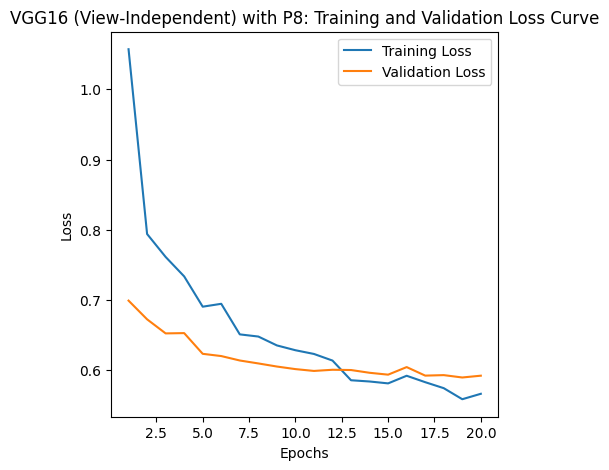

In [ ]:
# Training-Validation Loss curve for P8 pipeline
plot_training_validation_loss(vgg16_p8.history, 'VGG16 (View-Independent)', 'P8')

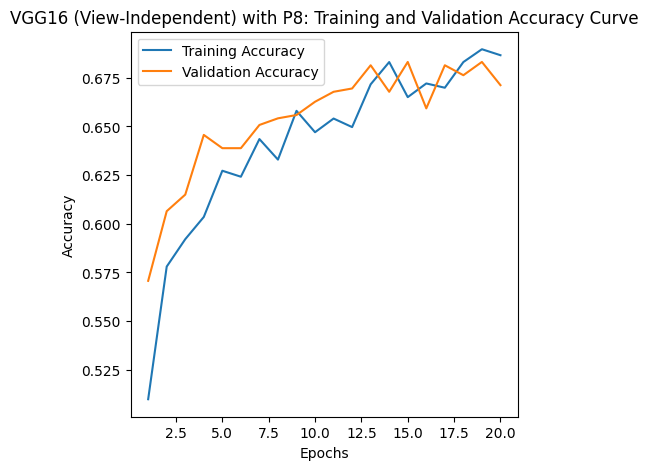

In [ ]:
# Training-Validation Accuracy curve for P8 pipeline
plot_training_validation_accuracy(vgg16_p8.history, 'VGG16 (View-Independent)', 'P8')

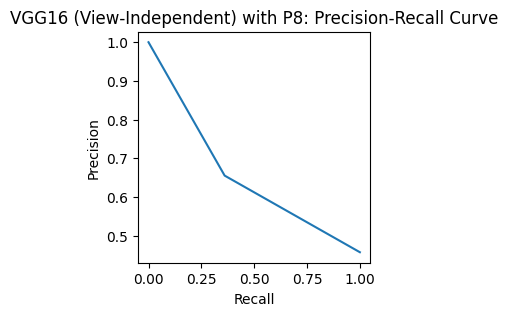

In [ ]:
# Precision-Recall curve for P8 Pipeline
plot_precision_recall_curve(true_pathology_np, predictions_p8, 'VGG16 (View-Independent)', 'P8')

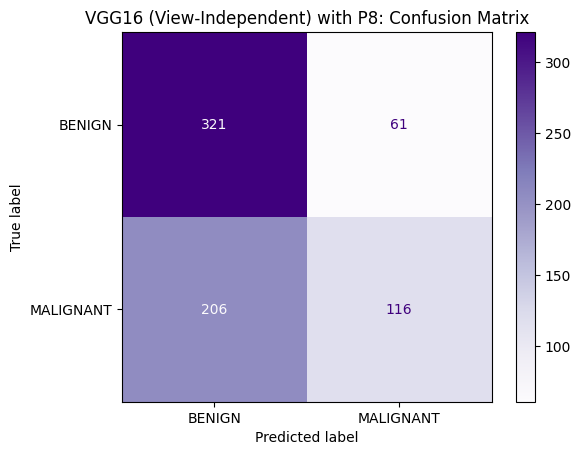

In [ ]:
# Confusion matrix for P8 pipeline
plot_confusion_matrix(true_pathology_np, predictions_p8, 'VGG16 (View-Independent)', 'P8')

## P9 Image Preprocessing Pipeline Experiment

* Resizing
* Gamma Correction
* Median Blur
* Normalization

In [ ]:
# Select the p9 image preprocessor function from the image preprocessor dictionary
p9 = IMAGE_PREPROCESSORS['P9']

In [ ]:
# Create a tf.data dataset with p9 image preprocessing
train_dataset_p9 = generate_dataset(train_df, 32, p9, 'vgg16', training=True)
val_dataset_p9 = generate_dataset(val_df, 32, p9, 'vgg16', training=False)
test_dataset_p9 = generate_dataset(test_df, 32, p9, 'vgg16', training=False)

In [ ]:
# Create a VGG16 model for p9 pipeline
vgg16_p9 = create_vgg16_model()
vgg16_p9 = compile_model(vgg16_p9)

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
# Train VGG16 with training dataset for p9 and compute its training time

# Reset memory for Peak GPU memory use computation
tf.config.experimental.reset_memory_stats('GPU:0')

# Training start time for p9
train_start_p9 = time.time()

# VGG16 with p9 training for 20 epochs
vgg16_p9.fit(train_dataset_p9, validation_data=val_dataset_p9, epochs=20)

# Memory used in p9
peak_memory_p9 = tf.config.experimental.get_memory_info('GPU:0')['peak']

# Training end time for p9
train_end_p9 = time.time()

# Total training time for p9 in minutes
training_time_p9 = (train_end_p9 - train_start_p9)

Epoch 1/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 59s 194ms/step - accuracy: 0.5253 - auc: 0.5262 - loss: 1.0562 - precision: 0.4146 - recall: 0.4723 - val_accuracy: 0.5809 - val_auc: 0.6163 - val_loss: 0.6669 - val_precision: 0.4600 - val_recall: 0.4000
Epoch 2/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 53s 189ms/step - accuracy: 0.5952 - auc: 0.6049 - loss: 0.8006 - precision: 0.4899 - recall: 0.4569 - val_accuracy: 0.6150 - val_auc: 0.6391 - val_loss: 0.6470 - val_precision: 0.5139 - val_recall: 0.3217
Epoch 3/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 54s 198ms/step - accuracy: 0.5952 - auc: 0.6210 - loss: 0.7607 - precision: 0.4896 - recall: 0.4414 - val_accuracy: 0.6303 - val_auc: 0.6506 - val_loss: 0.6375 - val_precision: 0.5468 - val_recall: 0.3304
Epoch 4/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 52s 190ms/step - accuracy: 0.6136 - auc: 0.6424 - loss: 0.7225 - precision: 0.5150 - recall: 0.4746 - val_accuracy: 0.6320 - val_auc: 0.6559 - val_loss: 0.6349 - val_precision: 0.5530 - val_recall: 0.3174
Epoch 5/20
72/72 ━━━━━━━━━━━

### P9 Image Preprocessing Predictions

In [ ]:
# Predict VGG16's prediction probabilities using test data for p9

# Prediction start time
predict_start_p9 = time.time()

# VGG16 with p9 predictions
prediction_probs_p9 = vgg16_p9.predict(test_dataset_p9)

# Prediction end time
predict_end_p9 = time.time()

# Total prediction time for p9 in seconds
prediction_time_p9 = predict_end_p9 - predict_start_p9

22/22 ━━━━━━━━━━━━━━━━━━━━ 6s 264ms/step


In [ ]:
# Evaluation metrics for VGG16 with p9
eval_metrics_p9 = vgg16_p9.evaluate(test_dataset_p9, return_dict=True)

22/22 ━━━━━━━━━━━━━━━━━━━━ 6s 261ms/step - accuracy: 0.5952 - auc: 0.6644 - loss: 0.6650 - precision: 0.6045 - recall: 0.3323


In [ ]:
# Compute predictions using model's prediction probabilities
predictions_p9 = np.where(prediction_probs_p9 > 0.5, 1.0, 0.0)

# Generate confusion matrix for p9 true and predicted values
tn_p9, fp_p9, fn_p9, tp_p9 = confusion_matrix(true_pathology, predictions_p9).ravel()

# Compute specificity using CM
specificity_p9 = tn_p9 / (tn_p9 + fp_p9)

# Compute F1 Score using recall and precision
f1_score_p9 = 0.0
if eval_metrics_p9['precision'] + eval_metrics_p9['recall'] != 0.0:
  f1_score_p9 = (2 * eval_metrics_p9['precision'] * eval_metrics_p9['recall']) / (eval_metrics_p9['precision'] + eval_metrics_p9['recall'])

# Parameters of VGG16 View-Independent model
vgg16_params_p9 = vgg16_p9.count_params()

In [ ]:
# Generate a results dataframe for results of p9 experiment
results_p9 = generate_results_df('VGG16', 'View_Independent', 'P9', eval_metrics_p9, specificity_p9, f1_score_p9, training_time_p9, prediction_time_p9, peak_memory_p9, vgg16_params_p9)

# Store p9 results into image preprocessing results csv
store_image_experiment_results(results_file_path, results_p9)

Stored results for 0    P9
Name: image_preprocessing_pipeline, dtype: object pipeline


### P9 Image Preprocessing Graphs

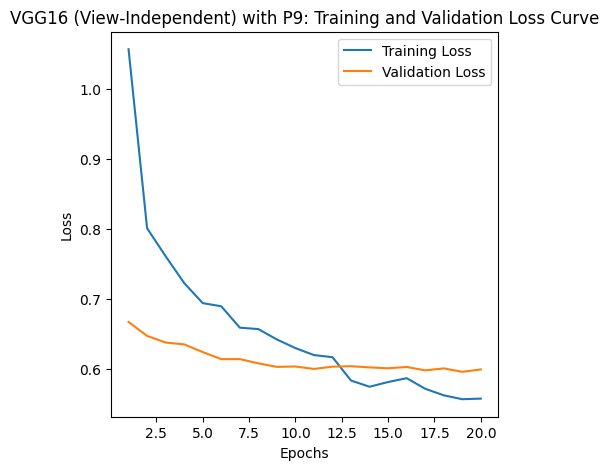

In [ ]:
# Training-Validation Loss curve for P9 pipeline
plot_training_validation_loss(vgg16_p9.history, 'VGG16 (View-Independent)', 'P9')

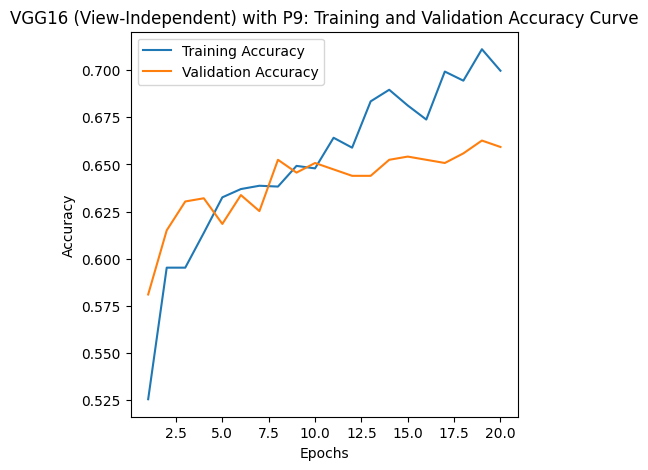

In [ ]:
# Training-Validation Accuracy curve for P9 pipeline
plot_training_validation_accuracy(vgg16_p9.history, 'VGG16 (View-Independent)', 'P9')

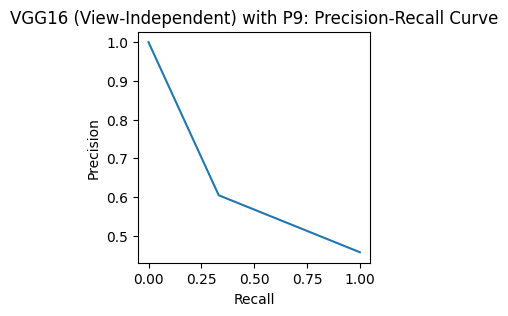

In [ ]:
# Precision-Recall curve for P9 Pipeline
plot_precision_recall_curve(true_pathology_np, predictions_p9, 'VGG16 (View-Independent)', 'P9')

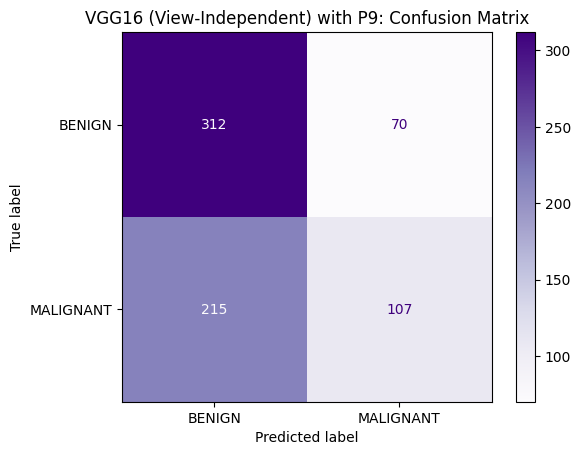

In [ ]:
# Confusion matrix for P9 pipeline
plot_confusion_matrix(true_pathology_np, predictions_p9, 'VGG16 (View-Independent)', 'P9')

## P10 Image Preprocessing Pipeline Experiment

* Resizing
* Grayscaling
* CLAHE
* Gamma Correction
* Median Blur
* Normalization

In [ ]:
# Select the p10 image preprocessor function from the image preprocessor dictionary
p10 = IMAGE_PREPROCESSORS['P10']

In [ ]:
# Create a tf.data dataset with p10 image preprocessing
train_dataset_p10 = generate_dataset(train_df, 32, p10, 'vgg16', training=True)
val_dataset_p10 = generate_dataset(val_df, 32, p10, 'vgg16', training=False)
test_dataset_p10 = generate_dataset(test_df, 32, p10, 'vgg16', training=False)

In [ ]:
# Create a VGG16 model for p10 pipeline
vgg16_p10 = create_vgg16_model()
vgg16_p10 = compile_model(vgg16_p10)

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step


In [ ]:
# Train VGG16 with training dataset for p10 and compute its training time

# Reset memory for Peak GPU memory use computation
tf.config.experimental.reset_memory_stats('GPU:0')

# Training start time for p10
train_start_p10 = time.time()

# VGG16 with p10 training for 20 epochs
vgg16_p10.fit(train_dataset_p10, validation_data=val_dataset_p10, epochs=20)

# Memory used in p10
peak_memory_p10 = tf.config.experimental.get_memory_info('GPU:0')['peak']

# Training end time for p10
train_end_p10 = time.time()

# Total training time for p10 in minutes
training_time_p10 = (train_end_p10 - train_start_p10)

Epoch 1/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 61s 195ms/step - accuracy: 0.5147 - auc: 0.5163 - loss: 1.1200 - precision: 0.4037 - recall: 0.4635 - val_accuracy: 0.5860 - val_auc: 0.6180 - val_loss: 0.6668 - val_precision: 0.4683 - val_recall: 0.4174
Epoch 2/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 54s 188ms/step - accuracy: 0.5859 - auc: 0.5933 - loss: 0.8201 - precision: 0.4778 - recall: 0.4524 - val_accuracy: 0.6320 - val_auc: 0.6418 - val_loss: 0.6520 - val_precision: 0.5565 - val_recall: 0.3000
Epoch 3/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 55s 192ms/step - accuracy: 0.5921 - auc: 0.6118 - loss: 0.7752 - precision: 0.4854 - recall: 0.4425 - val_accuracy: 0.6388 - val_auc: 0.6567 - val_loss: 0.6378 - val_precision: 0.5682 - val_recall: 0.3261
Epoch 4/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 55s 194ms/step - accuracy: 0.6167 - auc: 0.6353 - loss: 0.7387 - precision: 0.5189 - recall: 0.4856 - val_accuracy: 0.6457 - val_auc: 0.6605 - val_loss: 0.6404 - val_precision: 0.6038 - val_recall: 0.2783
Epoch 5/20
72/72 ━━━━━━━━━━━

### P10 Image Preprocessing Predictions

In [ ]:
# Predict VGG16's prediction probabilities using test data for p10

# Prediction start time
predict_start_p10 = time.time()

# VGG16 with p10 predictions
prediction_probs_p10 = vgg16_p10.predict(test_dataset_p10)

# Prediction end time
predict_end_p10 = time.time()

# Total prediction time for p10 in seconds
prediction_time_p10 = predict_end_p10 - predict_start_p10

22/22 ━━━━━━━━━━━━━━━━━━━━ 7s 293ms/step


In [ ]:
# Evaluation metrics for VGG16 with p10
eval_metrics_p10 = vgg16_p10.evaluate(test_dataset_p10, return_dict=True)

22/22 ━━━━━━━━━━━━━━━━━━━━ 6s 266ms/step - accuracy: 0.6094 - auc: 0.6599 - loss: 0.6653 - precision: 0.6374 - recall: 0.3385


In [ ]:
# Compute predictions using model's prediction probabilities
predictions_p10 = np.where(prediction_probs_p10 > 0.5, 1.0, 0.0)

# Generate confusion matrix for p10 true and predicted values
tn_p10, fp_p10, fn_p10, tp_p10 = confusion_matrix(true_pathology, predictions_p10).ravel()

# Compute specificity using CM
specificity_p10 = tn_p10 / (tn_p10 + fp_p10)

# Compute F1 Score using recall and precision
f1_score_p10 = 0.0
if eval_metrics_p10['precision'] + eval_metrics_p10['recall'] != 0.0:
  f1_score_p10 = (2 * eval_metrics_p10['precision'] * eval_metrics_p10['recall']) / (eval_metrics_p10['precision'] + eval_metrics_p10['recall'])

# Parameters of VGG16 View-Independent model
vgg16_params_p10 = vgg16_p10.count_params()

In [ ]:
# Generate a results dataframe for results of p10 experiment
results_p10 = generate_results_df('VGG16', 'View_Independent', 'P10', eval_metrics_p10, specificity_p10, f1_score_p10, training_time_p10, prediction_time_p10, peak_memory_p10, vgg16_params_p10)

# Store p10 results into image preprocessing results csv
store_image_experiment_results(results_file_path, results_p10)

Stored results for 0    P10
Name: image_preprocessing_pipeline, dtype: object pipeline


### P10 Image Preprocessing Graphs

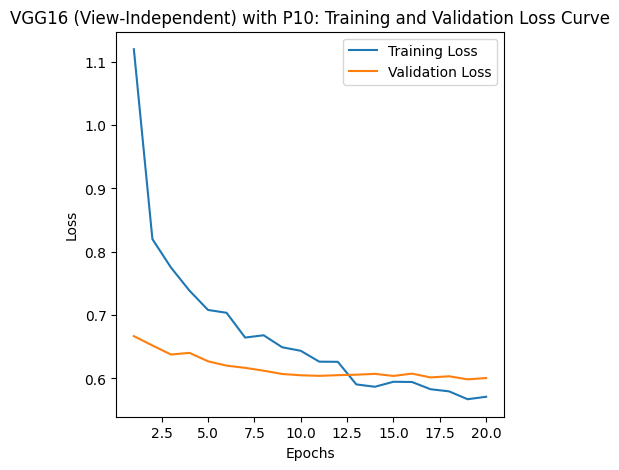

In [ ]:
# Training-Validation Loss curve for P10 pipeline
plot_training_validation_loss(vgg16_p10.history, 'VGG16 (View-Independent)', 'P10')

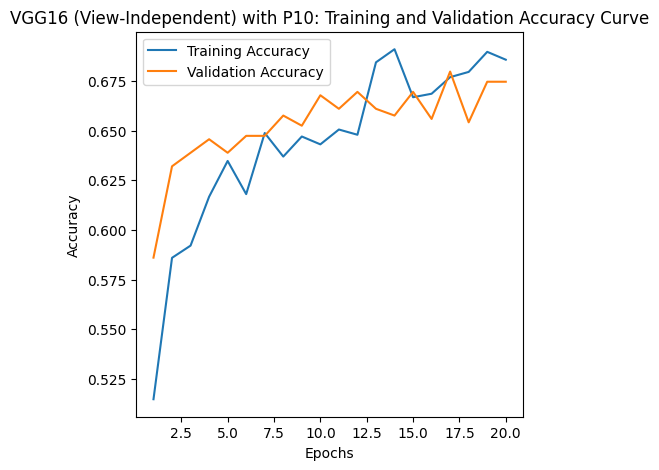

In [ ]:
# Training-Validation Accuracy curve for P10 pipeline
plot_training_validation_accuracy(vgg16_p10.history, 'VGG16 (View-Independent)', 'P10')

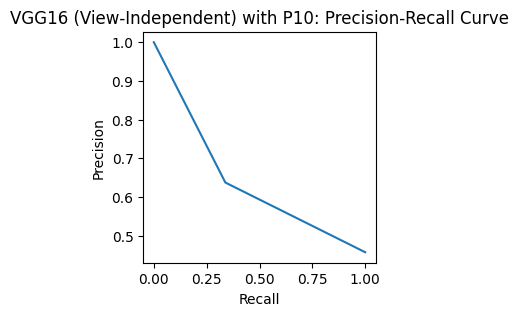

In [ ]:
# Precision-Recall curve for P10 Pipeline
plot_precision_recall_curve(true_pathology_np, predictions_p10, 'VGG16 (View-Independent)', 'P10')

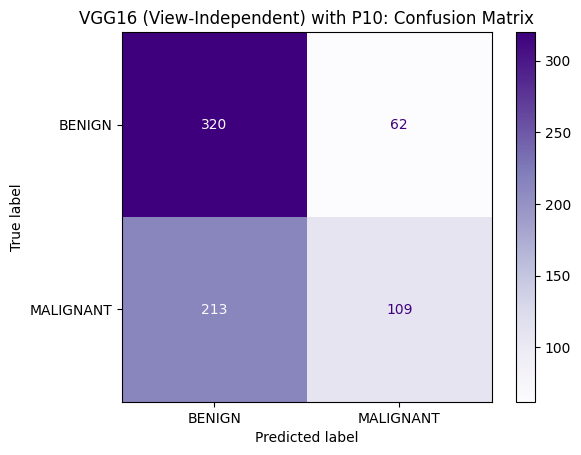

In [ ]:
# Confusion matrix for P10 pipeline
plot_confusion_matrix(true_pathology_np, predictions_p10, 'VGG16 (View-Independent)', 'P10')